In [1]:
import ee
import geemap
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path='.env')
project_name = os.getenv("project_name")
# print(f"Project Name: {project_name}")
ee.Initialize(project=project_name)


In [3]:
map = geemap.Map()

point = ee.Geometry.Point([90.4152, 23.8041]) #around dhaka
region = ee.Geometry.Rectangle([90.3, 23.7, 90.5, 23.9]) #bounding box around the point

map.centerObject(point, 10)
map.addLayer(point, {'color': 'red'}, 'Point Layer')
map.addLayer(region, {'color': 'blue'}, 'Region Layer')

map #just testing if everything is working

Map(center=[23.8041, 90.4152], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [4]:
#collecting data
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") #Sentinel-2 Surface Reflectance data

filtered_image = s2 \
    .filterBounds(region) \
    .sort('system:time_start')\
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    #.filterDate('2022-01-01', '2022-12-31') \
    

print(f"Number of images found: {filtered_image.size().getInfo()}")

Number of images found: 390


In [5]:
#now making sure they have full coverage of the region
strict_collection = filtered_image.filter(ee.Filter.contains(
        leftField='.geo', #.geo refers to the geometry of the image
        rightValue=region #the region we defined earlier 
    )
)

print(f"Number of images with full coverage: {strict_collection.size().getInfo()}")

Number of images with full coverage: 384


In [6]:
def add_ndvi(image):
    # calculating NDVI
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    #here ndvi = (NIR - RED) / (NIR + RED), NIR is band 8 and RED is band 4 in Sentinel-2
    
    # calculate the mean NDVI for the region immediately.
    stats = ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=20,
        maxPixels=1e9
    )
    
    # Return the image with the NDVI band and the calculated mean value set as a property
    return image.addBands(ndvi).set('mean_ndvi', stats.get('NDVI'))

In [7]:
ndvi_collection = strict_collection.map(add_ndvi)

ndvi_collection = ndvi_collection.filter(ee.Filter.notNull(['mean_ndvi']))
#clearing any images where mean_ndvi is null
print(f"Number of images with NDVI: {ndvi_collection.size().getInfo()}")

Number of images with NDVI: 384


In [8]:
min_timestamp = ndvi_collection.aggregate_min("system:time_start")
max_timestamp = ndvi_collection.aggregate_max("system:time_start")
print(f"Min Timestamp: {min_timestamp.getInfo()}")
print(f"Max Timestamp: {max_timestamp.getInfo()}")
print('First Date:', ee.Date(min_timestamp).format('YYYY-MM-dd').getInfo())
print('Last Date:', ee.Date(max_timestamp).format('YYYY-MM-dd').getInfo())

Min Timestamp: 1453092113893
Max Timestamp: 1766032934402
First Date: 2016-01-18
Last Date: 2025-12-18


In [9]:

import datetime

# Visualization parameters for NDVI (green = high vegetation, red/brown = low vegetation)
ndvi_vis = {
    'min': 0,
    'max': 0.8,
    'palette': ['brown', 'yellow', 'green', 'darkgreen']
}

# Convert NDVI to RGB for video export
def visualize_ndvi(image):
    return image.select('NDVI').visualize(**ndvi_vis)

# Apply visualization to the collection
visualized_collection_ndvi = ndvi_collection.map(visualize_ndvi)

now = datetime.datetime.now()
time_stamp = now.strftime("%Y_%m_%d_%H_%M_%S")

file_name = 'NDVI_Timelapse_' + time_stamp
print('Exporting file as:', file_name)

# Create the export task
task = ee.batch.Export.video.toDrive(
    collection=visualized_collection_ndvi,  # Use visualized collection instead
    folder='GEE_Exports',
    description=file_name,
    dimensions=720,    
    framesPerSecond=10, 
    region=region
)

task.start()


Exporting file as: NDVI_Timelapse_2026_01_05_21_16_26


In [10]:
try:
    while task.active():
        print('Polling for task (id: {task.id}). Current status: {task.status()}')
        print(task)
        import time
        time.sleep(30)
    print('Done.', task.status())
except KeyboardInterrupt:
    print('stopped')

Polling for task (id: {task.id}). Current status: {task.status()}
<Task A5SKMDFRUSCYVZ3IXCM72XJ5 Type.EXPORT_VIDEO: NDVI_Timelapse_2026_01_05_21_16_26 (State.UNSUBMITTED)>
Polling for task (id: {task.id}). Current status: {task.status()}
<Task A5SKMDFRUSCYVZ3IXCM72XJ5 Type.EXPORT_VIDEO: NDVI_Timelapse_2026_01_05_21_16_26 (State.UNSUBMITTED)>
Polling for task (id: {task.id}). Current status: {task.status()}
<Task A5SKMDFRUSCYVZ3IXCM72XJ5 Type.EXPORT_VIDEO: NDVI_Timelapse_2026_01_05_21_16_26 (State.UNSUBMITTED)>
Polling for task (id: {task.id}). Current status: {task.status()}
<Task A5SKMDFRUSCYVZ3IXCM72XJ5 Type.EXPORT_VIDEO: NDVI_Timelapse_2026_01_05_21_16_26 (State.UNSUBMITTED)>
Polling for task (id: {task.id}). Current status: {task.status()}
<Task A5SKMDFRUSCYVZ3IXCM72XJ5 Type.EXPORT_VIDEO: NDVI_Timelapse_2026_01_05_21_16_26 (State.UNSUBMITTED)>
Polling for task (id: {task.id}). Current status: {task.status()}
<Task A5SKMDFRUSCYVZ3IXCM72XJ5 Type.EXPORT_VIDEO: NDVI_Timelapse_2026_01_0

[1453092113893, 1453092114658, 1483332111832, 1483332112591, 1485924112088, 1509684105209, 1520484113878, 1520484114655, 1544676109459, 1544676110228, 1545540110000, 1545540110000, 1545972114000, 1545972115000, 1546404112000, 1546404112807, 1546836116000, 1546836117164, 1547268113000, 1547268114277, 1547700117515, 1547700118286, 1548132114000, 1548132115214, 1548564118000, 1548564118000, 1548996114000, 1548996115000, 1549428118000, 1549428118000, 1549860114000, 1549860115413, 1550724113000, 1550724114000, 1551588112000, 1551588113502, 1552020115000, 1552020116000, 1553316116000, 1553316117000, 1553748119000, 1553748120000, 1555476123000, 1555476124000, 1555908121000, 1555908121801, 1557204126076, 1557204126858, 1558068127000, 1568868117663, 1568868118432, 1571028119107, 1571028119870, 1571460121094, 1571460121875, 1572324121157, 1572324121937, 1573620116932, 1573620117693, 1574052119346, 1574052120125, 1574484114915, 1574484115673, 1574916117508, 1574916118281, 1575348112275, 157534811

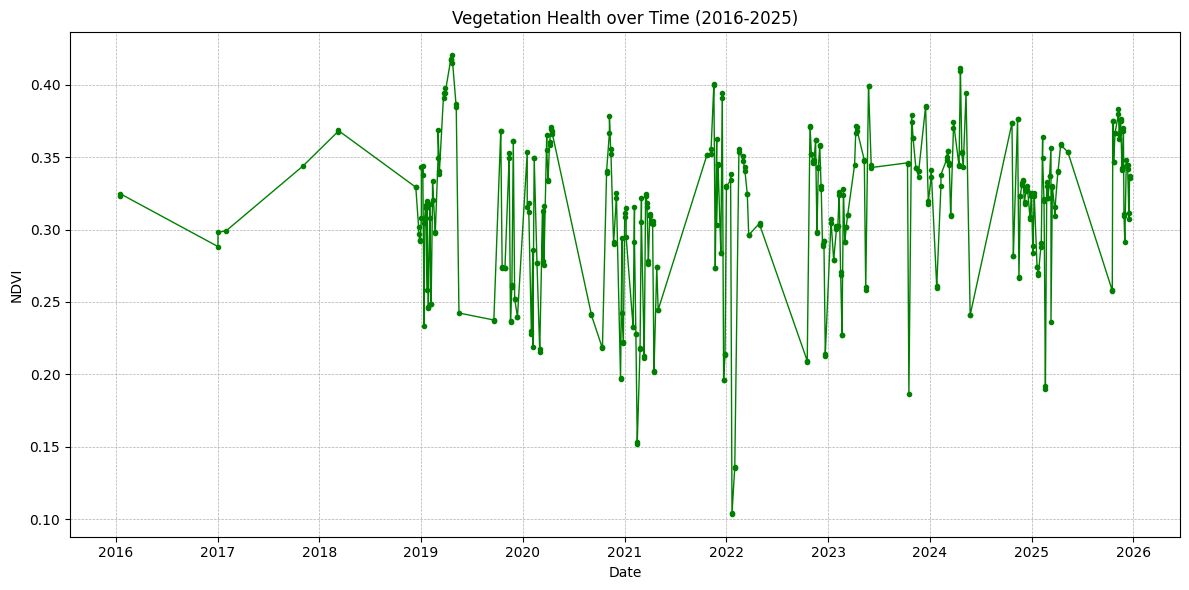

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

dates_server = ndvi_collection.aggregate_array('system:time_start') #getting the time_start property for each image
ndvi_server = ndvi_collection.aggregate_array('mean_ndvi') #getting the mean_ndvi property for each image
# print(dates_server)
# print(ndvi_server)
dates = dates_server.getInfo()
values = ndvi_server.getInfo()
print(dates, values)

df = pd.DataFrame({
    'date': dates,
    'ndvi': values
})

#millisecond timestamp to a readable datetime format
df['date'] = pd.to_datetime(df['date'], unit='ms')


plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['ndvi'], color='green', marker='o', markersize=3, linestyle='-', linewidth=1)


plt.title('Vegetation Health over Time (2016-2025)')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)


plt.tight_layout()
plt.show()